In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# check pytorch working
print(torch.__version__)
print("PyTorch working!" )

2.11.0
PyTorch working!


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [7]:
print("Data ready!")
print("X_train shape:", X_train.shape)


Data ready!
X_train shape: torch.Size([455, 30])


CancerNN(
  (layer1): Linear(in_features=30, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (layer3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Epoch 0 | Loss: 0.7200
Epoch 10 | Loss: 0.6670
Epoch 20 | Loss: 0.6008
Epoch 30 | Loss: 0.5134
Epoch 40 | Loss: 0.4078
Epoch 50 | Loss: 0.3070
Epoch 60 | Loss: 0.2298
Epoch 70 | Loss: 0.1774
Epoch 80 | Loss: 0.1431
Epoch 90 | Loss: 0.1199
Accuracy: 0.9737


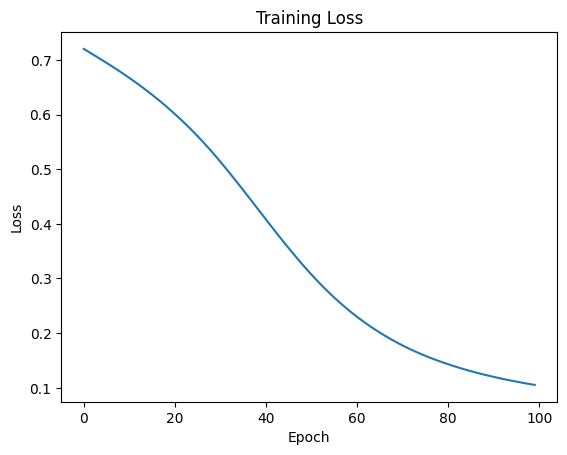

In [8]:
# ── 2. Build Neural Network ───────────────────
class CancerNN(nn.Module):
    def __init__(self):
        super(CancerNN, self).__init__()
        self.layer1 = nn.Linear(30, 32)  # 30 inputs → 32 neurons
        self.layer2 = nn.Linear(32, 16)  # 32 → 16 neurons
        self.layer3 = nn.Linear(16, 1)   # 16 → 1 output
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))    # layer 1
        x = self.relu(self.layer2(x))    # layer 2
        x = self.sigmoid(self.layer3(x)) # output
        return x

model = CancerNN()
print(model)

# ── 3. Train ──────────────────────────────────
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
for epoch in range(100):
    # forward pass
    y_pred = model(X_train).squeeze()
    loss = criterion(y_pred, y_train)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# ── 4. Evaluate ───────────────────────────────
with torch.no_grad():
    y_pred_test = model(X_test).squeeze()
    y_pred_class = (y_pred_test > 0.5).float()
    accuracy = (y_pred_class == y_test).float().mean()
    print(f"Accuracy: {accuracy:.4f}")

# ── 5. Plot Loss ──────────────────────────────
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()